# Module 2: Predicting the reported biodiversity impact of Sustainable Land Management (SLM) technologies with supervised learning

**Research question:** Together with the data, WOCAT sent us a question that fits a supervised approach: which features of an SLM technology predict a large improvement in biodiversity? WOCAT is mainly interested in one indicator, **biomass / above-ground C** (questionnaire section 6.1), the living plant matter and carbon stored above the soil surface. This notebook answers that question, and adds one WOCAT could ask next: among the documented SLM methods, which go with the largest reported biomass gains once we account for where they are applied?

**What this notebook builds on**

* Dima's data exploration gave us the tidy tables and two rules we follow throughout. Firstly, cross-validation is **grouped in space** because sites and compilers cluster geographically, we also tried countries and the K-means cluster from the module 1 notebook. This notebook groups by blocks of nearby sites, because a country is too large and too uneven a unit (section 3). Secondly the scores are **reported** impact, never a causal effect: compiler averages differ by two points on a seven-point scale. 
* Norman's Module 1 clustering showed that the structure of the data is dominated by the agro-climatic zone. Environment first, practice second.

**What we do**

* One classical **yardstick**: logistic regression, the same thing as a network with no hidden layers. Its coefficients give the feature importances the research plan asks for. A second logistic regression uses a feature that turned out to matter, the number of answers the compiler ticked.
* **Method 1, a regularised feed-forward network**, with He initialisation, batch normalisation, dropout, L2, Adam, a learning-rate schedule and early stopping. It is kept small, one hidden layer of 16 units, because on 479 rows the closer a network stays to logistic regression, the better it does. A wide and deep network is the comparison, and a multi-task network that also predicts all eight indicators of section 6.1 was tried (end of section 5).
* **The answer:** The network ranks the SLM methods as if they had all been applied in the same environments, and the agro-climatic zones as if they all carried the same practices. A permutation test shows which feature blocks the network actually uses.

**Key results, in short:** The questionnaire predicts a technology's reported biomass gain only modestly: AUC 0.57 on unseen regions with all 102 fields of the research plan. *Two integers*, the number of degradation types and measures a technology ticks, do better than all the fields (0.64), and the neural networks add nothing. With the environment held fixed, agroforestry, drainage (on 17 records), ground cover and forest lead the SLM groups while water harvesting and crop-livestock integration trail, but the whole ranking spans only thirteen probability points. The clearest environmental signal is the agro-climatic zone: arid and semi-arid sites report top biomass scores 1.5 to 2 times as often as humid and sub-humid ones. Section 6.4 has the full synthesis.

Run time: about 4 minutes on a laptop CPU, with numpy, pandas, scikit-learn, matplotlib, tensorflow and keras.


## 1. Setup


In [1]:
import os, sys, time, warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"   # reproducible numerics on CPU

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import sklearn
import tensorflow as tf
import keras
from keras import layers

warnings.filterwarnings("ignore", category=FutureWarning); warnings.filterwarnings("ignore", category=DeprecationWarning)
tf.get_logger().setLevel("ERROR")
SEED = 42
keras.utils.set_random_seed(SEED)

print(f"python {sys.version.split()[0]} | pandas {pd.__version__} | scikit-learn {sklearn.__version__} | "
      f"tensorflow {tf.__version__} | keras {keras.__version__}")

# plotting conventions
C_BLUE, C_ORANGE, C_AQUA, C_RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
C_PURPLE, C_GOLD, C_PINK = "#8155c6", "#c9960c", "#d14a8f"
INK, INK_MUTED, GRID, NEUTRAL = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
plt.rc("font", size=11); plt.rc("axes", titlesize=12, edgecolor=NEUTRAL, labelcolor=INK, axisbelow=True)
plt.rc("axes.spines", top=False, right=False); plt.rc("grid", color=GRID, linewidth=0.8)
plt.rc("xtick", color=INK_MUTED); plt.rc("ytick", color=INK_MUTED); plt.rc("legend", frameon=False, fontsize=10)


python 3.13.14 | pandas 3.0.5 | scikit-learn 1.9.1 | tensorflow 2.21.0 | keras 3.15.1


## 2. Data and targets

Two tables from Dima's exploration, one row per technology (1 540 rows) and one row per individual impact score (23 802 rows), joined with the water block of questionnaire section 5.4 and the cost breakdowns of sections 4.4 and 4.6 (one row per technology). The biodiversity block of the questionnaire (section 6.1) asks for a rating from -3 to +3 on eight indicators. A technology is scored only on the indicators its compiler considered relevant. The research plan names one of them as the main output: **biomass / above-ground C**. The other seven are optional outputs.


In [2]:
def find_data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "colab" / "datasets" / "wocat"
        if (candidate / "wocat_technologies.csv.gz").is_file():
            return candidate
    raise FileNotFoundError("run this notebook from inside the CAS-AML-WOCAT repository")

DATA = find_data_dir(); REPO = DATA.parents[2]
wocat = pd.read_csv(DATA / "wocat_technologies.csv.gz")
scores = pd.read_csv(DATA / "impact_scores.csv.gz")

# the research plan's water and cost inputs, extracted separately (water_and_costs/README.md has the caveats)
water = pd.read_csv(REPO / "water_and_costs" / "water_availability.csv")
costs = pd.read_csv(REPO / "water_and_costs" / "costs_summary.csv")
wocat = (wocat.merge(water[["technology_id", "groundwater", "surfacewater"]], on="technology_id", how="left")
              .merge(costs[["technology_id", "establishment_total_usd", "maintenance_total_usd"]], on="technology_id", how="left"))
# The USD totals are not per hectare, not inflation-adjusted and span eight orders of magnitude, so each cost enters as
# its quartile among all 1 540 technologies; a missing figure becomes a category of its own, like every other missing answer.
COST_LEVELS = ["Q1 lowest", "Q2", "Q3", "Q4 highest"]
for phase in ["establishment", "maintenance"]:
    wocat[f"{phase}_cost"] = pd.qcut(wocat[f"{phase}_total_usd"], 4, labels=COST_LEVELS).astype(object)

PRETTY = {"vegetation_cover": "Vegetation cover", "biomass_above_ground_C": "Biomass / above-ground C",
          "plant_diversity": "Plant diversity", "animal_diversity": "Animal diversity",
          "beneficial_species": "Beneficial species", "habitat_diversity": "Habitat diversity",
          "invasive_alien_species": "Invasive alien species", "pest_disease_control": "Pest / disease control"}
BIO = list(PRETTY)
TARGET = "biomass_above_ground_C"          # the research plan's main output variable

bio_wide = (scores[scores["block"] == "ecological_biodiversity"]
            .pivot_table(index="technology_id", columns="indicator", values="value", aggfunc="mean").reindex(columns=BIO))
bio_all = wocat.merge(bio_wide, left_on="technology_id", right_index=True, how="inner").reset_index(drop=True)
data = bio_all[bio_all[TARGET].notna()].reset_index(drop=True)   # the technologies that score biomass
MEDIAN = data[TARGET].median()
data["bio_high"] = (data[TARGET] > MEDIAN).astype(int)
y = data["bio_high"].to_numpy()
Y_IND = data[BIO].to_numpy(dtype=np.float32)          # NaN where an indicator was not scored

print(f"{len(wocat):,} technologies, {len(scores):,} individual scores; {len(bio_all)} technologies score at least one "
      f"biodiversity indicator, {len(data)} of them score biomass / above-ground C")
print(f"biomass score: median = {MEDIAN:+.0f}; share above {MEDIAN:+.0f} ('high') = {y.mean():.2f}; "
      f"share at or above {MEDIAN:+.0f} = {(data[TARGET] >= MEDIAN).mean():.2f}")

scored = bio_all[BIO].notna()
print(pd.DataFrame({"scored (all 895)": scored.sum().values, f"scored (the {len(data)} biomass records)": data[BIO].notna().sum().values,
                    "mean score": bio_all[BIO].mean().round(2).values, "share > 0": ((bio_all[BIO] > 0).sum() / scored.sum()).round(2).values},
                   index=[PRETTY[b] for b in BIO]).to_string())


1,540 technologies, 23,802 individual scores; 895 technologies score at least one biodiversity indicator, 479 of them score biomass / above-ground C
biomass score: median = +2; share above +2 ('high') = 0.30; share at or above +2 = 0.68
                          scored (all 895)  scored (the 479 biomass records)  mean score  share > 0
Vegetation cover                       350                               200        1.86       0.96
Biomass / above-ground C               479                               479        1.92       0.95
Plant diversity                        475                               291        1.75       0.93
Animal diversity                       249                               157        1.52       0.89
Beneficial species                     281                               175        1.64       0.94
Habitat diversity                      338                               208        1.54       0.88
Invasive alien species                  98                     

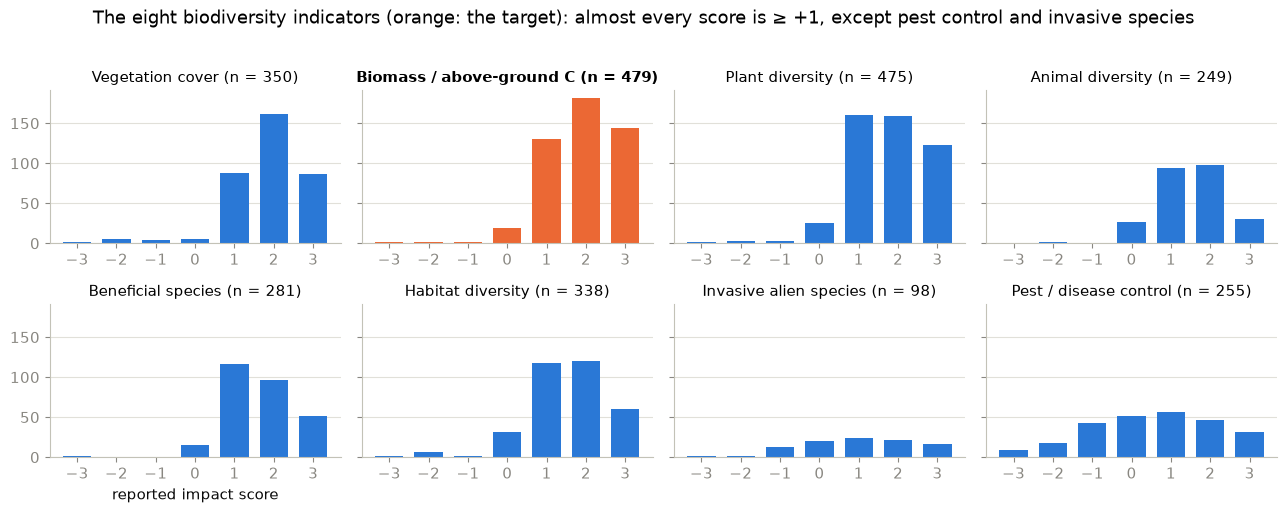

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5), sharey=True)
for ax, b in zip(axes.ravel(), BIO):
    counts = bio_all[b].round().value_counts().reindex(range(-3, 4), fill_value=0)
    ax.bar(counts.index, counts.values, color=C_ORANGE if b == TARGET else C_BLUE, width=0.72)
    ax.set_title(f"{PRETTY[b]} (n = {int(bio_all[b].notna().sum())})", fontsize=10.5, fontweight="bold" if b == TARGET else "normal")
    ax.set_xticks(range(-3, 4)); ax.grid(True, axis="y")
axes[1, 0].set_xlabel("reported impact score")
fig.suptitle("The eight biodiversity indicators (orange: the target): almost every score is ≥ +1, except pest control and invasive species", y=1.02)
plt.tight_layout(); plt.show()

**Target:** The research question asks which technologies report a *high* rather than a *low* improvement, so the target is a cut between the two, and the median is the natural place for it. The label `bio_high` is 1 when a technology's biomass / above-ground C score sits above the median. The scores are whole numbers and the median is +2, a single step that holds 38 % of the records, so "above the median" means **the top rating +3 against +2 or less**: 144 high against 335 low, a 30 / 70 split. "At or above the median" would count +2 as high as well (68 / 32). We keep the strict rule. We also tested the other split and the full seven-step scale: a model handed all seven steps separates the top scores from the rest no better.

**Imbalance:** AUC is the main metric, because it depends neither on a threshold nor on the class balance. For macro-F1 each model flags the top 30 % or so of its test fold by predicted probability (`scores_from` in section 3 states the rule). We do not use class weights: they would distort the predicted probabilities, and section 6.2 reads those directly.

Only 479 of the 895 technologies with a biodiversity score rate biomass, so every model below trains and tests on those 479. The full notebook also uses the mean of the eight indicator columns as an alternative target.


## 3. Features and the spatial-block split

The inputs are the Module 2 fields of the research plan, one-hot or multi-hot encoded into 102 binary features, with missing answers as their own category. The three essential practice fields are the **SLM group, the SLM measures and the land degradation addressed** (questionnaire sections 3.5 to 3.7). The four essential environment and cost fields are the groundwater table and the availability of surface water (5.4) and the cost of establishment and of maintenance (4.4, 4.6), the costs as USD quartiles. The optional fields are the main purpose, the current land use, the water supply, the agro-climatic zone and the slope. A **block** column groups the fields into environment, cost, land use and the four practice fields separately (SLM group, measures, degradation, main purpose) for the coefficient plot of section 4 and the permutation test of section 6.3. Coordinates, country and compiler are not features: they would let the model memorise regions and raters, which does not transfer to unseen regions. The other impact blocks of the form, cost-benefit and adoption are outcome-like and stay out as well.

**Split:** Five folds, stratified on the label and grouped by ***spatial block***, fixed once and reused by every model. A block is one of 30 k-means clusters of the site coordinates, taken on the unit sphere so that the date line needs no care: a region of nearby sites, in the median 13 technologies from 2 countries and about 1 300 km across, cut by proximity rather than by border. A country is too uneven a unit: 40 of the 87 countries hold one or two records and Tajikistan alone holds 42. The 36 records without usable coordinates are grouped by country. Inside each training fold, a further block-grouped 15 % serves as the validation set for early stopping. The test fold is never touched during training.


In [4]:
# the research plan's input fields, in the blocks of the table above
ENVIRONMENT = ["agroclimatic_zone", "slope", "watersupply", "groundwater", "surfacewater"]
COST = ["establishment_cost", "maintenance_cost"]
LAND_USE = ["landuse"]
PRACTICE = ["slm_group", "measures", "degradation", "main_purpose"]
WATER_COST = ["groundwater", "surfacewater", *COST]    # the research plan's water and cost inputs
SINGLE, MULTI = ENVIRONMENT + COST, LAND_USE + PRACTICE
BLOCK_OF = {**{c: "environment" for c in ENVIRONMENT}, **{c: "cost" for c in COST}, **{c: "land use" for c in LAND_USE},
            "slm_group": "SLM group", "measures": "measures",   # the practice fields stay apart: as one block they
            "degradation": "degradation", "main_purpose": "main purpose"}   # would carry 14 of the 15 largest coefficients

from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, f1_score

def tokens(series):
    return series.apply(lambda v: v.split("|") if isinstance(v, str) and v else ["MISSING"])

def encode_onehot(df):
    frames = []
    for col in SINGLE:
        enc = OneHotEncoder(sparse_output=False, dtype=np.float32)
        arr = enc.fit_transform(df[[col]].fillna("MISSING").astype(str))
        frames.append(pd.DataFrame(arr, columns=[f"{col}={c}" for c in enc.categories_[0]], index=df["technology_id"]))
    for col in MULTI:
        mlb = MultiLabelBinarizer()
        arr = mlb.fit_transform(tokens(df[col]).tolist()).astype(np.float32)
        frames.append(pd.DataFrame(arr, columns=[f"{col}={c}" for c in mlb.classes_], index=df["technology_id"]))
    return pd.concat(frames, axis=1)

X_df = encode_onehot(wocat).loc[data["technology_id"]]
X = X_df.to_numpy(dtype=np.float32)
FIELD_OF = {c: c.split("=")[0] for c in X_df.columns}
N_BLOCKS = 30   # k-means blocks on the site coordinates: a country is too large and too uneven a unit to hold out

def site_xyz(df):
    """Usable coordinates as points on the unit sphere (so the date line needs no care), and which records have them."""
    lat, lon = df["latitude"].to_numpy(dtype=float), df["longitude"].to_numpy(dtype=float)
    has = np.isfinite(lat) & np.isfinite(lon) & (np.abs(lat) <= 90) & (np.abs(lon) <= 180)
    lat, lon = np.radians(lat[has]), np.radians(lon[has])
    return has, np.column_stack([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)])

def spatial_groups(df):
    """One group label per record: the k-means block of its site, or the country for records without usable coordinates."""
    has, xyz = site_xyz(df)
    labels = np.array([f"country:{c}" for c in df["country_name"]], dtype=object)
    labels[has] = [f"block:{b}" for b in KMeans(n_clusters=N_BLOCKS, random_state=SEED, n_init=10).fit_predict(xyz)]
    return labels

groups = spatial_groups(data)

FOLDS = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(X, y, groups))

def inner_split(train_idx, seed=SEED):
    tr, va = next(GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=seed).split(train_idx, groups=groups[train_idx]))
    return train_idx[tr], train_idx[va]

def scores_from(y_true, p, share_train):
    """AUC needs no threshold. Macro-F1 flags the top share_train of the fold by predicted probability
    (as many records as the training fold has 'high' ones): a quantile of the model's own predictions, so a model whose
    probabilities sit uniformly too high or too low is not punished twice. A constant prediction flags nothing."""
    yhat = (p > np.quantile(p, 1.0 - share_train)).astype(int)
    return {"AUC": roc_auc_score(y_true, p), "macro-F1": f1_score(y_true, yhat, average="macro")}

RESULTS = {}
def record(name, fold_scores, seconds):
    RESULTS[name] = {"folds": fold_scores, "seconds": seconds}
    df = pd.DataFrame(fold_scores)
    print(f"{name:40s} AUC {df['AUC'].mean():.3f} ± {df['AUC'].std():.3f}   macro-F1 {df['macro-F1'].mean():.3f} ± {df['macro-F1'].std():.3f}   ({seconds:4.0f} s)")

has, xyz = site_xyz(data); blocks = pd.Series(groups[has]); country_of = pd.Series(data["country_name"].to_numpy()[has])
span_km = {b: 6371 * np.arccos(np.clip(xyz[blocks == b] @ xyz[blocks == b].T, -1, 1)).max() for b in blocks.unique()}
print(f"{X.shape[0]} technologies x {X.shape[1]} features; {blocks.nunique()} spatial blocks, in the median "
      f"{blocks.value_counts().median():.0f} technologies from {country_of.groupby(blocks).nunique().median():.0f} countries and "
      f"{np.median(list(span_km.values())):,.0f} km across; {(~has).sum()} records without usable coordinates are grouped by country")
print(pd.DataFrame([{"fold": k, "train": len(tr), "test": len(te), "test groups": len(set(groups[te])), "test countries": data["country_name"].iloc[te].nunique(),
                     "share high (test)": round(y[te].mean(), 2)} for k, (tr, te) in enumerate(FOLDS)]).to_string(index=False))

479 technologies x 102 features; 30 spatial blocks, in the median 13 technologies from 2 countries and 1,292 km across; 36 records without usable coordinates are grouped by country
 fold  train  test  test groups  test countries  share high (test)
    0    387    92           11              17                0.3
    1    385    94           12              14                0.3
    2    382    97           11              21                0.3
    3    385    94           11              29                0.3
    4    377   102            7              29                0.3


## 4. Yardstick: logistic regression

One classical model on the same folds. Logistic regression is the same model as a neural network with zero hidden layers, so the gap between it and the networks below measures exactly what hidden layers add: interactions between features. (A majority-class guess scores AUC 0.5 by construction, and a random forest of 500 trees came out level with logistic regression on the country-grouped folds of an earlier run, with the same features at the top. Neither is shown.)

The signed coefficients answer the research plan's question of how important the input features are. The cell after them compares feature sets on the same folds: the water and cost fields, the other plan fields, and the number of answers ticked. Coefficients are read only for columns present in at least 20 of the 479 records. Below that, a share of top scores cannot be told from the base rate.


In [5]:
from sklearn.linear_model import LogisticRegression

make_logreg = lambda: LogisticRegression(C=0.3, max_iter=5000)

def cv_sklearn(make_model, X_, y_, folds):
    out = []
    for tr, te in folds:
        model = make_model().fit(X_[tr], y_[tr])
        out.append(scores_from(y_[te], model.predict_proba(X_[te])[:, 1], y_[tr].mean()))
    return out

def run_sklearn_cv(name, make_model):
    t0 = time.time()
    record(name, cv_sklearn(make_model, X, y, FOLDS), time.time() - t0)

NAME_0A = f"Logistic regression ({X.shape[1]} fields)"
run_sklearn_cv(NAME_0A, make_logreg)


Logistic regression (102 fields)         AUC 0.570 ± 0.074   macro-F1 0.544 ± 0.045   (   0 s)


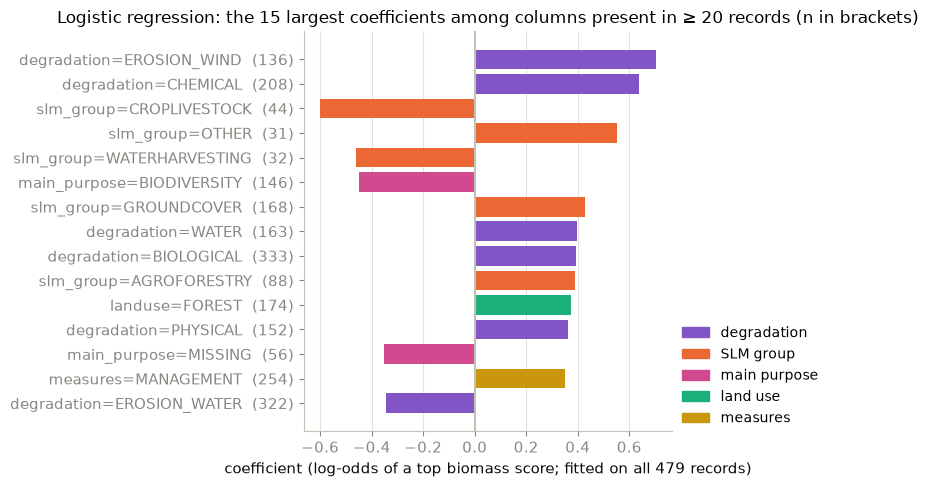

52 of 102 coefficients positive; blocks in the top 15: {'degradation': 6, 'SLM group': 5, 'main purpose': 2, 'land use': 1, 'measures': 1}
25 columns are present in fewer than 20 records and are not read; the largest among them: landuse=WATERWAYS -0.45 (19), slm_group=DRAINAGE +0.45 (17), slope=MISSING +0.44 (9), measures=OTHER +0.37 (14)

                                  block  coefficient  records  share high | present  share high | absent  difference
degradation=EROSION_WIND    degradation        0.702      136                 0.426                0.251       0.176
degradation=CHEMICAL        degradation        0.638      208                 0.389                0.232       0.157
slm_group=CROPLIVESTOCK       SLM group       -0.599       44                 0.159                0.315      -0.156
slm_group=OTHER               SLM group        0.553       31                 0.419                0.292       0.127
slm_group=WATERHARVESTING     SLM group       -0.461       32            

In [6]:
logreg = make_logreg().fit(X, y)          # one fit on all 479 records; the cells below read its coefficients
coef = pd.Series(logreg.coef_[0], index=X_df.columns)

MIN_SUPPORT = 20   # a coefficient is read only if its column is present in at least this many of the 479 records (section 6.2 uses 15 for the what-if)
support = X_df.sum(axis=0).astype(int)
readable = coef[(support >= MIN_SUPPORT).to_numpy()]
imp = readable.reindex(readable.abs().sort_values(ascending=False).index).head(15)   # the 15 largest coefficients, sign kept
present = {f: (X_df[f] == 1).to_numpy() for f in imp.index}
direction = pd.DataFrame({"block": [BLOCK_OF[FIELD_OF[f]] for f in imp.index],
                          "coefficient": imp.values,
                          "records": [support[f] for f in imp.index],
                          "share high | present": [y[present[f]].mean() for f in imp.index],
                          "share high | absent": [y[~present[f]].mean() for f in imp.index]}, index=imp.index)
direction["difference"] = direction["share high | present"] - direction["share high | absent"]
label_n = lambda f: f"{f}  ({support[f]})"

fig, ax = plt.subplots(figsize=(8.5, 5))
colours = {"environment": C_BLUE, "cost": C_RED, "land use": C_AQUA, "SLM group": C_ORANGE,
           "degradation": C_PURPLE, "main purpose": C_PINK, "measures": C_GOLD}
ax.barh([label_n(f) for f in imp.index[::-1]], imp.values[::-1], color=[colours[BLOCK_OF[FIELD_OF[c]]] for c in imp.index[::-1]])
ax.axvline(0, color=NEUTRAL)
ax.legend(handles=[Patch(color=colours[b], label=b) for b in dict.fromkeys(direction["block"])],
          loc="lower left", bbox_to_anchor=(1.01, 0.0), borderaxespad=0.0)   # outside the axes, clear of the bars
ax.set_xlabel("coefficient (log-odds of a top biomass score; fitted on all 479 records)")
ax.set_title(f"Logistic regression: the 15 largest coefficients among columns present in ≥ {MIN_SUPPORT} records (n in brackets)"); ax.grid(True, axis="x")
plt.tight_layout(); plt.show()
below = coef[(support < MIN_SUPPORT).to_numpy()]
print(f"{(coef > 0).sum()} of {len(coef)} coefficients positive; blocks in the top 15: {direction['block'].value_counts().to_dict()}")
print(f"{len(below)} columns are present in fewer than {MIN_SUPPORT} records and are not read; the largest among them: "
      + ", ".join(f"{f} {coef[f]:+.2f} ({support[f]})" for f in below.abs().sort_values(ascending=False).index[:4]) + "\n")
print(direction.round(3).to_string())


In [7]:
ticked = pd.DataFrame({f: tokens(data[f]).apply(lambda t: 0 if t == ["MISSING"] else len(t))
                       for f in ["degradation", "measures"]})   # answers ticked per record
# feature sets against each other, same model and folds: what is in the fields vs. how many answers are ticked
X_water_cost = X_df.loc[:, [c for c in X_df.columns if FIELD_OF[c] in WATER_COST]].to_numpy(dtype=np.float32)
X_without_water_cost = X_df.loc[:, [c for c in X_df.columns if FIELD_OF[c] not in WATER_COST]].to_numpy(dtype=np.float32)
X_counts = ticked.to_numpy(dtype=np.float32)
count_rows = []
for feats, Xv in [("the water and cost fields only", X_water_cost), ("the other plan fields", X_without_water_cost), ("all plan fields (section 3)", X),
                  ("two counts only (degradation types, measures)", X_counts), ("all plan fields + two counts", np.hstack([X, X_counts]))]:
    auc = pd.DataFrame(cv_sklearn(make_logreg, Xv, y, FOLDS))["AUC"]
    count_rows.append({"features": feats, "columns": Xv.shape[1], "AUC": auc.mean(), "sd": auc.std()})
print(pd.DataFrame(count_rows).round(3).to_string(index=False))
print()
t0 = time.time()
record("Logistic regression (two counts)", cv_sklearn(make_logreg, X_counts, y, FOLDS), time.time() - t0)


                                     features  columns   AUC    sd
               the water and cost fields only       20 0.449 0.093
                        the other plan fields       82 0.612 0.093
                  all plan fields (section 3)      102 0.570 0.074
two counts only (degradation types, measures)        2 0.637 0.041
                 all plan fields + two counts      104 0.578 0.073

Logistic regression (two counts)         AUC 0.637 ± 0.041   macro-F1 0.578 ± 0.048   (   0 s)


**Reading the coefficients:** The plot keeps to the 77 columns present in at least 20 records. Four of the fifteen largest coefficients of the unrestricted fit fall below that line, a missing slope answer (9 records), drainage (17), "other" measures (14) and waterways (19). None of the water and cost fields reaches the fifteen, and no environment field does. A coefficient is the change in the log-odds of a +3 when a technology ticks that answer, everything else held fixed, so the +0.70 of wind erosion doubles the odds. Read against [WOCAT's questionnaire](https://wocat.net/documents/447/QT_English_2019_CClicence.docx) (QT 2019, sections 3.1 and 3.5 to 3.7), the fifteen fall into four patterns.

* **Five answers describe biomass from the input side.** WOCAT defines *improved ground/vegetation cover* (+0.43) as "any measures that aim to improve the ground cover, be it by dead material/mulch or vegetation", and *biological degradation* (+0.39) carries the sub-code "Bq: quantity/biomass decline". *Agroforestry* (+0.39), forest as the land use (+0.37) and *management measures* (+0.35, area closure and resting, which "often result in improved vegetative cover") grow vegetation by definition. The tick and the +3 describe the same plants from two sides.
* **The two largest have a mechanism.** *Soil erosion by wind* (+0.70) is the loss of topsoil from bare, dry ground, and its remedies are vegetative: 72 % of its 136 records tick vegetative measures, and two thirds sit in the semi-arid or arid zone against half overall. A shelterbelt on bare ground is a large biomass gain. *Chemical soil deterioration* (+0.64) is defined first as "fertility decline and reduced soil organic matter content", and its records are cropland (85 %) treated with compost and manure, where the biomass indicator is the crop. Both also mark a long degradation list, 3.6 types ticked against 2.1 to 2.4, so part of each coefficient is thoroughness.
* **The negatives produce something other than standing vegetation.** *Water harvesting* (-0.46) is "the collection and management of floodwater or rainwater runoff to increase water availability": 94 % of its 32 records are structural, and their gains are booked in the water block, half a point above the rest, while biomass gets a +1 in 44 % of cases. *Integrated crop-livestock management* (-0.60) "optimizes the uses of crop and livestock resources through interaction", so residues are fed rather than left standing.
* **A biodiversity purpose (-0.45) looks wrong and is an artefact of the cut.** Its 146 records rate biomass slightly *higher* on average, +1.95 against +1.90, and higher on every other biodiversity indicator. But 47 % of them sit at exactly +2 against 34 % of the rest, and the median split counts a +2 as "not high". Without a cut the coefficient is -0.14 with an interval that includes zero.

The remaining five, water erosion (-0.35), a missing main purpose (-0.35), "other" as the SLM group (+0.55), water degradation (+0.40) and physical deterioration (+0.36), are marks of the +3 cut or of how the form was filled in, and the full notebook's bootstrap leaves none of the fifteen with an interval away from zero in every reading. The coefficients are fitted on all 479 records at once, so they describe the fit. Section 6.3 asks what transfers to unseen regions.

**The water and cost fields carry no signal.** On their own their twenty columns score AUC 0.45, below chance. Adding the four fields to the other 82 costs 0.04 AUC (0.612 to 0.570), the price of twenty more columns on 479 rows.

**Two integers beat 102 fields.** A logistic regression on just two counts, the number of degradation types and the number of measures a technology ticks, reaches AUC 0.637, the full model 0.570, and both together 0.578. Nothing the individual answers say adds to what the number of answers says. A technology that tackles many problems at once may really build more biomass, but the count is also a trace of how thoroughly the compiler filled in the form. It is the rater effect Dima warned about, reaching the model through a feature this time rather than through the scores. The count model enters the results table of section 6.1 as the second yardstick, and every later result has to be read against it.


## 5. A regularised feed-forward network

A multilayer perceptron on the 102 one-hot features, built with the Module 2 training toolbox:

| technique | what it does here |
|---|---|
| He initialisation | keeps activations at a sane scale through the layers |
| ReLU | non-saturating, no vanishing gradient |
| Batch normalisation | normalises inside the network, allows a larger learning rate (`use_bias=False` before it) |
| Dropout + L2 | the two regularisers that matter most with 479 rows |
| Adam | adaptive per-weight learning rates |
| `ReduceLROnPlateau` | halves the learning rate when the validation loss stalls |
| Early stopping | stops when the validation loss stops improving, restores the best weights |

We first show the failure mode without regularisation, then the regularised network, then the network we keep against a wide and deep one. **The network is small on purpose:** one hidden layer of 16 units with a strong L2 penalty (1e-2), about 1 700 parameters for about 320 training rows. The comparison after the loss curves puts it against a 128-64 network with 22 000 parameters and a ten times weaker L2 penalty, the configuration a reader would reach for by default. That network buys nothing here, though the gap between the two is inside the seed spread. What does run the wrong way for depth is the ladder against the logistic regressions of section 4. Every cross-validated network result is a mean over **5 folds and 3 seeds** (`run_keras_seeds`), because with about 380 training rows the random seed alone moves a network's AUC by several hundredths. One handicap to keep in mind: early stopping needs a validation set, so a network trains on about 323 of a fold's 380 rows and watches the other 57, while the yardstick of section 4 fits all 380.

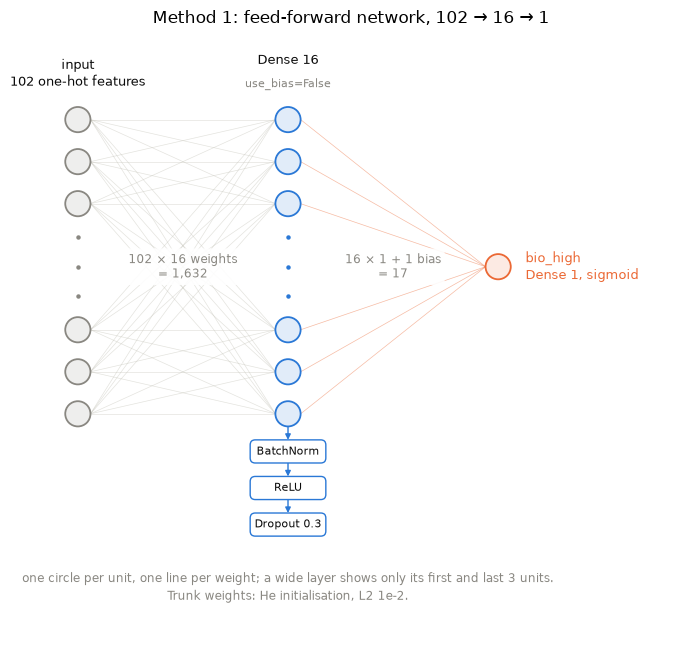

In [8]:
# draw_network draws the architecture below.
from matplotlib.colors import to_rgb
from matplotlib.patches import FancyBboxPatch

def draw_network(ax, n_in, hidden, heads, note=None):
    """One column per layer, one circle per unit, one line per weight. A layer wider than 8 units shows
    only its first and last 3 units and an ellipsis. heads: (units, activation, name, colour) per output layer."""
    show, r, dx = 3, 0.3, 5.0                 # units shown per side of a wide layer, circle radius, column spacing
    tint = lambda c: tuple(1 - 0.14 * (1 - v) for v in to_rgb(c))
    low, high = [0.0], [0.0]                  # the extreme y drawn so far, for the axis limits

    def ys_of(n, centre):                     # y of the circles drawn for an n-unit layer centred at `centre`
        if n <= 2 * show + 2:
            return [centre + (n - 1) / 2 - i for i in range(n)]
        return [centre + show + 0.5 - i for i in range(show)] + [centre - 1.5 - i for i in range(show)]

    def column(x, n, colour, centre=0.0):
        ys = ys_of(n, centre)
        for y in ys:
            ax.add_patch(plt.Circle((x, y), r, facecolor=tint(colour), edgecolor=colour, linewidth=1.3, zorder=3))
        if len(ys) < n:
            ax.plot([x] * 3, [centre + 0.7, centre, centre - 0.7], "o", ms=2.2, color=colour, zorder=3)
        low.append(min(ys) - r); high.append(max(ys) + r)
        return ys

    def connect(x0, ys0, x1, ys1, colour, label, label_y):
        for a in ys0:
            for b in ys1:
                ax.plot([x0 + r, x1 - r], [a, b], color=colour, linewidth=0.5, alpha=0.45, zorder=1)
        ax.text((x0 + x1) / 2, label_y, label, ha="center", va="center", fontsize=8.5, color=INK_MUTED, zorder=4,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.9))

    def ops(x, y, colour):                    # what every unit of the column then goes through, in this order
        gap, h = 0.32, 0.55                   # arrow length and box height of each step
        for step in ("BatchNorm", "ReLU", "Dropout 0.3"):
            ax.annotate("", xy=(x, y - gap), xytext=(x, y), zorder=2,
                        arrowprops=dict(arrowstyle="-|>", color=colour, lw=1.0, shrinkA=0, shrinkB=0, mutation_scale=8))
            ax.add_patch(FancyBboxPatch((x - 0.9, y - gap - h), 1.8, h, boxstyle="round,pad=0,rounding_size=0.12",
                                        facecolor="white", edgecolor=colour, linewidth=1.0, zorder=3))
            ax.text(x, y - gap - h / 2, step, ha="center", va="center", fontsize=7.8, color=INK, zorder=4)
            y -= gap + h
        low.append(y)

    x, ys, n = 0.0, column(0.0, n_in, INK_MUTED), n_in
    ax.text(0, max(ys) + r + 0.4, f"input\n{n_in} one-hot features", ha="center", va="bottom", fontsize=9.5, color=INK)
    for units in hidden:                      # the trunk: Dense -> BatchNorm -> ReLU -> Dropout per hidden layer
        ys_new = column(x + dx, units, C_BLUE)
        connect(x, ys, x + dx, ys_new, NEUTRAL, f"{n} × {units} weights\n= {n * units:,}", 0.0)
        ax.text(x + dx, max(ys_new) + r + 0.95, f"Dense {units}", ha="center", va="bottom", fontsize=9.5, color=INK)
        ax.text(x + dx, max(ys_new) + r + 0.4, "use_bias=False", ha="center", va="bottom", fontsize=8, color=INK_MUTED)
        ops(x + dx, min(ys_new) - r, C_BLUE)
        x, ys, n = x + dx, ys_new, units
    heights = [min(u, 2 * show + 2) for u, *_ in heads]
    top = (sum(heights) + 1.5 * (len(heads) - 1)) / 2
    for (units, activation, name, colour), h in zip(heads, heights):   # the head(s), fully connected to the last trunk layer
        centre = top - h / 2
        ys_h = column(x + dx, units, colour, centre)
        connect(x, ys, x + dx, ys_h, colour, f"{n} × {units} + {units} bias\n= {n * units + units:,}", centre / 2)
        ax.text(x + dx + r + 0.35, centre, f"{name}\nDense {units}, {activation}", ha="left", va="center", fontsize=9.5, color=colour)
        top -= h + 1.5
    if note:
        ax.text((x + dx) / 2, min(low) - 0.8, note, ha="center", va="top", fontsize=8.5, color=INK_MUTED, linespacing=1.5)
    ax.set_xlim(-1.5, x + dx + 4.5); ax.set_ylim(min(low) - (2.4 if note else 0.6), max(high) + 1.8)
    ax.set_aspect("equal"); ax.axis("off")

fig, ax = plt.subplots(figsize=(8, 6.6))
draw_network(ax, X.shape[1], (16,), [(1, "sigmoid", "bio_high", C_ORANGE)],      # the helper defined above
             note="one circle per unit, one line per weight; a wide layer shows only its first and last 3 units.\n"
                  "Trunk weights: He initialisation, L2 1e-2.")
ax.set_title(f"Method 1: feed-forward network, {X.shape[1]} → 16 → 1")
plt.tight_layout(); plt.show()


In [9]:
def dense_trunk(h, hidden, dropout, l2, batchnorm=True):
    reg = keras.regularizers.l2(l2) if l2 else None
    for units in hidden:
        h = layers.Dense(units, kernel_initializer="he_normal", use_bias=not batchnorm, kernel_regularizer=reg)(h)
        if batchnorm:
            h = layers.BatchNormalization()(h)
        h = layers.Activation("relu")(h)
        if dropout:
            h = layers.Dropout(dropout)(h)
    return h

def build_mlp(hidden=(16,), dropout=0.3, l2=1e-2, batchnorm=True):
    inp = keras.Input(shape=(X.shape[1],), name="onehot")
    # one line on purpose: Python constructs the head before the trunk here, and every layer draws its initializer seed
    # when constructed, so splitting this line reorders the seeds and moves the AUCs quoted below by 0.02
    out = layers.Dense(1, activation="sigmoid", name="bio_high")(dense_trunk(inp, hidden, dropout, l2, batchnorm))
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
    return model

def callbacks():
    return [keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)]

def run_keras_cv(build, Xany, seed):
    """Grouped 5-fold CV for a Keras model whose output is the bio_high sigmoid.
    build(train_idx) returns a compiled model. Returns (fold scores, fitted models)."""
    out, models = [], []
    for k, (tr, te) in enumerate(FOLDS):
        keras.utils.clear_session(); keras.utils.set_random_seed(seed + k)
        tr_in, va_in = inner_split(tr, seed + k)
        model = build(tr_in)
        model.fit(Xany[tr_in], y[tr_in], validation_data=(Xany[va_in], y[va_in]),
                  epochs=150, batch_size=32, callbacks=callbacks(), verbose=0)
        p = model.predict(Xany[te], verbose=0).ravel()
        out.append(scores_from(y[te], p, y[tr].mean())); models.append(model)
    return out, models

SEEDS = (SEED, 7, 123)
def run_keras_seeds(build, Xany, name=None):
    """run_keras_cv once per seed. On ~380 training rows the seed alone moves a network's AUC by several
    hundredths, so every network result below is a mean over 5 folds x 3 seeds. Models come back seed by seed,
    fold by fold: models[i] was tested on (FOLDS * len(SEEDS))[i]."""
    t0, out, models = time.time(), [], []
    for s in SEEDS:
        fold_scores, fold_models = run_keras_cv(build, Xany, seed=s)
        out += fold_scores; models += fold_models
    if name:
        record(name, out, time.time() - t0)
    return out, models

build_mlp().summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ onehot (InputLayer)             │ (None, 102)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bio_high (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,713 (6.69 KB)

 Trainable params: 1,681 (6.57 KB)

 Non-trainable params: 32 (128.00 B)

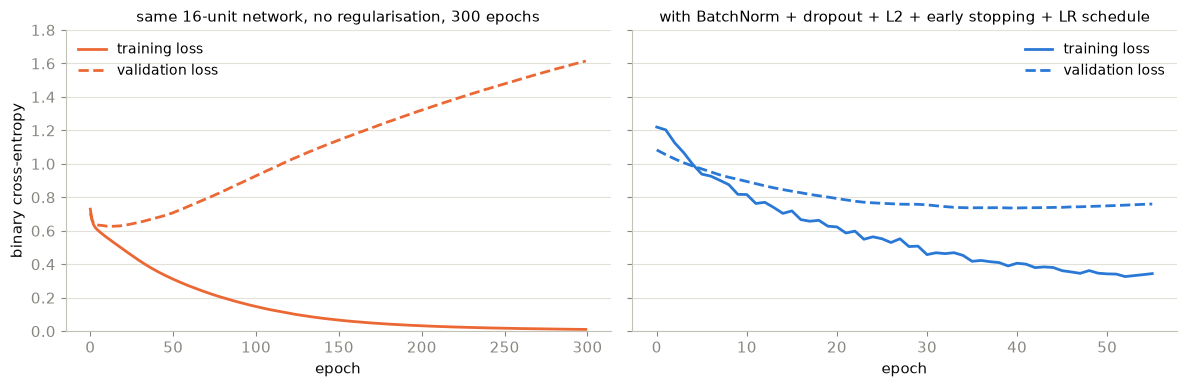

fold-0 test AUC: naive 0.436 (300 epochs)  |  regularised 0.417 (stopped after 56 epochs)


In [10]:
tr0, te0 = FOLDS[0]; tr_in0, va_in0 = inner_split(tr0)
NAIVE_EPOCHS = 300   # the same 16-unit network with the toolbox off needs about 300 epochs to memorise the fold at this learning rate
keras.utils.set_random_seed(SEED)
naive = build_mlp(dropout=0.0, l2=0.0, batchnorm=False)
h_naive = naive.fit(X[tr_in0], y[tr_in0], validation_data=(X[va_in0], y[va_in0]), epochs=NAIVE_EPOCHS, batch_size=32, verbose=0)
keras.utils.set_random_seed(SEED)
regular = build_mlp()
h_reg = regular.fit(X[tr_in0], y[tr_in0], validation_data=(X[va_in0], y[va_in0]), epochs=150, batch_size=32, callbacks=callbacks(), verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, hist, title, colour in [(axes[0], h_naive.history, f"same 16-unit network, no regularisation, {NAIVE_EPOCHS} epochs", C_ORANGE),
                                (axes[1], h_reg.history, "with BatchNorm + dropout + L2 + early stopping + LR schedule", C_BLUE)]:
    ax.plot(hist["loss"], color=colour, linewidth=2, label="training loss")
    ax.plot(hist["val_loss"], color=colour, linewidth=2, linestyle="--", label="validation loss")
    ax.set_title(title, fontsize=11); ax.set_xlabel("epoch"); ax.legend(); ax.grid(True, axis="y")
axes[0].set_ylabel("binary cross-entropy"); axes[0].set_ylim(0, 1.8)
plt.tight_layout(); plt.show()
print(f"fold-0 test AUC: naive {roc_auc_score(y[te0], naive.predict(X[te0], verbose=0).ravel()):.3f} ({NAIVE_EPOCHS} epochs)  |  "
      f"regularised {roc_auc_score(y[te0], regular.predict(X[te0], verbose=0).ravel()):.3f} (stopped after {len(h_reg.history['loss'])} epochs)")

Both panels train the same 16-unit network on the same ~300 rows of fold 0 and watch the same held-out slice. Left, with the toolbox switched off: the network memorises its training rows. The training loss falls to zero over 300 epochs, while the validation loss turns upward after about ten epochs and never comes back. Right, with the toolbox: the validation loss falls, flattens after about thirty epochs, and early stopping ends training after about fifty-five. (Both curves on the right include the L2 penalty, which is why they start above the left-hand ones.) The single-fold test AUCs printed above come from one fold of 92 records and one seed. That both networks land below chance on this fold, the regularised one under the naive one, is exactly the kind of noise the next cell averages away. What this cell shows is the shape of the two loss curves, not which network scores better.

**Size:** The next cell trains the small network and a wide, deep one (128-64, dropout 0.3, L2 1e-4) on the same grouped folds with three seeds. The two rows differ in penalty as well as in width, so this compares two candidate configurations rather than isolating size. (Choosing between two candidates on the folds we report is slightly optimistic, by a fraction of an AUC point.)

In [11]:
SIZES = {"small (16), L2 1e-2": dict(hidden=(16,), dropout=0.3, l2=1e-2),
         "wide and deep (128-64), L2 1e-4": dict(hidden=(128, 64), dropout=0.3, l2=1e-4)}
sizes, small, models_small = [], None, None
for label, cfg in SIZES.items():
    t0 = time.time()
    fold_scores, models = run_keras_seeds(lambda idx: build_mlp(**cfg), X)
    seconds = time.time() - t0
    df = pd.DataFrame(fold_scores).assign(seed=np.repeat(SEEDS, len(FOLDS)))
    per_seed = df.groupby("seed", sort=False)["AUC"].mean()
    sizes.append({"config": label, "parameters": models[0].count_params(), "AUC": df["AUC"].mean(),
                  **{f"AUC seed {s}": per_seed[s] for s in SEEDS}, "macro-F1": df["macro-F1"].mean(), "seconds": seconds})
    if small is None:
        small, models_small = (fold_scores, seconds), models   # section 6 reuses these 15 models
print(pd.DataFrame(sizes).round(3).to_string(index=False))
print()
record("Feed-forward net (16 units)", *small)


                         config  parameters   AUC  AUC seed 42  AUC seed 7  AUC seed 123  macro-F1  seconds
            small (16), L2 1e-2        1713 0.550        0.544       0.575         0.530     0.527   67.363
wide and deep (128-64), L2 1e-4       22081 0.539        0.502       0.530         0.585     0.528   48.866

Feed-forward net (16 units)              AUC 0.550 ± 0.095   macro-F1 0.527 ± 0.061   (  67 s)


The small network scores AUC 0.550, the wide and deep one 0.539, and the three seeds do not agree on the order (0.544 against 0.502 on one seed, 0.530 against 0.585 on another), so the two are level. Logistic regression, the network with no hidden layer, scores 0.570 and the two-count model 0.637. So the ladder runs the wrong way for depth: the closer a model stays to logistic regression, the better it does. On 479 rows of one-hot answers, hidden layers find no interactions worth their extra variance, and what the regularisation toolbox buys is training that is stable and stops by itself, not a higher score. We can say so only because the two logistic regressions are there to compare against.


**Multi-task network:** We also trained this trunk with two heads as a second method: the biomass high/low sigmoid and eight linear outputs, one per indicator of questionnaire section 6.1, trained with a masked mean squared error that ignores the indicators a compiler did not score. Two results follow from it, both on the same folds and seeds. On the shared high/low head it is level with the single-head network, AUC 0.532 against 0.550, inside the seed spread, so eight extra targets do not regularise the trunk into a better classifier. On unseen regions it predicts none of the eight indicators better than that indicator's training mean (skill between -0.22 and +0.01, biomass -0.07): the questionnaire separates the top biomass rating from the rest and locates very little else. The presentation keeps the single-head network, whose predictions the what-if of section 6.2 reads.


## 6. Results: which methods go with the largest reported biomass gains?

### 6.1 All models on the same folds


In [12]:
def summary_table():
    rows = []
    for name, r in RESULTS.items():
        df = pd.DataFrame(r["folds"])
        rows.append({"approach": name, "AUC": df["AUC"].mean(), "AUC sd": df["AUC"].std(), "macro-F1": df["macro-F1"].mean(),
                     "macro-F1 sd": df["macro-F1"].std(), "seconds": r["seconds"]})
    return pd.DataFrame(rows)
table = summary_table()
print(table.round(3).to_string(index=False))


                        approach   AUC  AUC sd  macro-F1  macro-F1 sd  seconds
Logistic regression (102 fields) 0.570   0.074     0.544        0.045    0.043
Logistic regression (two counts) 0.637   0.041     0.578        0.048    0.037
     Feed-forward net (16 units) 0.550   0.095     0.527        0.061   67.363


Logistic regression on the 102 fields (AUC 0.570) and on the two counts (0.637) are within one fold-to-fold standard deviation of each other. The network sits 0.09 AUC below the count model. Its standard deviation pools seed variance with fold variance, 15 values against 5. With the quantile threshold the macro-F1 column tells the same story. Every model is above chance, but not by much: AUC 0.6 means that out of a random pair of one +3 record and one lower record, the model ranks the +3 higher 60 % of the time.

The full notebook reruns the yardstick on twelve variants of the problem. How the folds are cut moves the AUC by 0.05 (0.57 to 0.62), the water and cost fields cost 0.04, and the looser split, +2 and +3 against the rest, costs 0.02, so every number in this notebook should be read with a width of about 0.05.


### 6.2 Raw ranking vs. environment-adjusted what-if

The raw ranking mixes what a method does with *where* it is used: forest technologies sit in humid zones, water harvesting in arid ones. The 16-unit network of section 5 separates the two with a counterfactual. If every one of the 479 technologies had used method g, in its own climate, slope, water, costs and land use, what would the network expect? We switch every technology's SLM-group indicators to *only* g, leave everything else untouched, and predict **out of fold**: each record is scored only by the three models that did not train on it, one per seed, and the 479 scores are averaged. Grey is the raw share of +3 biomass scores among technologies listing the group, blue the what-if probability. The cell after the plot repeats the what-if for the agro-climatic zone with practice and land use held fixed.


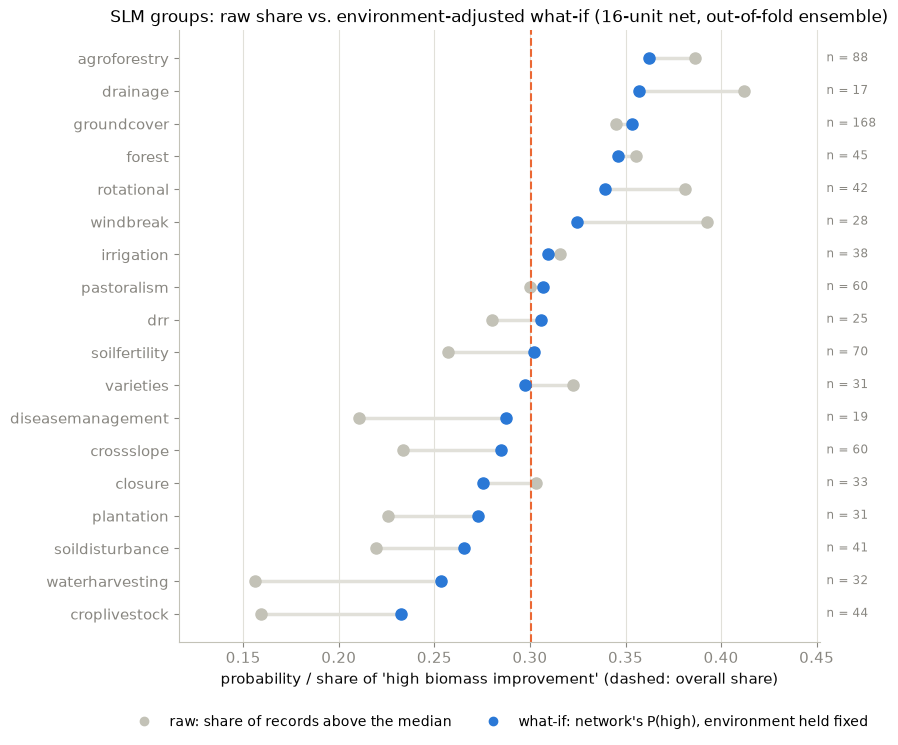

out-of-fold mean P(high) on the records as they are: 0.320; share of high records: 0.301

                     n  mean rating  raw share high  adjusted P(high)
AGROFORESTRY        88        2.091           0.386             0.362
DRAINAGE            17        2.118           0.412             0.357
GROUNDCOVER        168        2.030           0.345             0.353
FOREST              45        2.044           0.356             0.346
ROTATIONAL          42        2.095           0.381             0.339
WINDBREAK           28        2.036           0.393             0.325
IRRIGATION          38        1.895           0.316             0.310
PASTORALISM         60        1.817           0.300             0.307
DRR                 25        1.760           0.280             0.306
SOILFERTILITY       70        1.871           0.257             0.302
VARIETIES           31        1.742           0.323             0.297
DISEASEMANAGEMENT   19        1.789           0.211             0.288


In [13]:
long = data[["bio_high", TARGET]].assign(group=tokens(data["slm_group"])).explode("group")
share_high = long.groupby("group")["bio_high"].mean()
n_group = long.groupby("group").size()
GROUPS_SHOWN = [g for g in n_group.index if n_group[g] >= 15 and g not in ("MISSING", "OTHER")]
SLM_COL = {c.split("=")[1]: j for j, c in enumerate(X_df.columns) if c.startswith("slm_group=")}

MODEL_FOLDS = list(zip(models_small, FOLDS * len(SEEDS)))   # models_small[i] was tested on (FOLDS * len(SEEDS))[i]

def oof_predict(Xany):
    """Out-of-fold ensemble: every record is predicted only by the models that did not train on it (one per seed),
    and the seeds are averaged. Returns P(high) per record."""
    p_high = np.zeros((len(SEEDS), len(Xany)))
    for i, (m, (_, te)) in enumerate(MODEL_FOLDS):
        p_high[i // len(FOLDS), te] = m.predict(Xany[te], verbose=0).ravel()
    return p_high.mean(axis=0)

def what_if(category):
    Xc = X.copy(); Xc[:, list(SLM_COL.values())] = 0.0; Xc[:, SLM_COL[category]] = 1.0
    return oof_predict(Xc).mean()

P_OOF = oof_predict(X)   # the records as they are, scored out of fold
adjusted = pd.DataFrame({"adjusted P(high)": {g: what_if(g) for g in GROUPS_SHOWN}})
adjusted["raw share high"] = share_high.reindex(adjusted.index); adjusted["n"] = n_group.reindex(adjusted.index)
adjusted["mean rating"] = long.groupby("group")[TARGET].mean().reindex(adjusted.index)
adjusted = adjusted.sort_values("adjusted P(high)")

fig, ax = plt.subplots(figsize=(9, 0.32 * len(adjusted) + 1.8))
for i, (g, r) in enumerate(adjusted.iterrows()):
    ax.plot([r["raw share high"], r["adjusted P(high)"]], [i, i], color=GRID, linewidth=2.5, zorder=1)
    ax.plot(r["raw share high"], i, "o", color=NEUTRAL, markersize=8, zorder=2)
    ax.plot(r["adjusted P(high)"], i, "o", color=C_BLUE, markersize=8, zorder=3)
    ax.text(1.01, i, f"n = {int(r['n'])}", va="center", fontsize=8.5, color=INK_MUTED, transform=ax.get_yaxis_transform())
ax.plot([], [], "o", color=NEUTRAL, label="raw: share of records above the median")
ax.plot([], [], "o", color=C_BLUE, label="what-if: network's P(high), environment held fixed")
ax.axvline(y.mean(), color=C_ORANGE, linestyle="--", linewidth=1.5)
values = adjusted[["raw share high", "adjusted P(high)"]].to_numpy()
ax.set_yticks(range(len(adjusted)), [g.lower() for g in adjusted.index]); ax.set_xlim(values.min() - 0.04, values.max() + 0.04)
ax.set_xlabel("probability / share of 'high biomass improvement' (dashed: overall share)")
ax.set_title("SLM groups: raw share vs. environment-adjusted what-if (16-unit net, out-of-fold ensemble)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2); ax.grid(True, axis="x")
plt.tight_layout(); plt.show()
print(f"out-of-fold mean P(high) on the records as they are: {P_OOF.mean():.3f}; share of high records: {y.mean():.3f}\n")
print(adjusted[["n", "mean rating", "raw share high", "adjusted P(high)"]].round(3).sort_values("adjusted P(high)", ascending=False).to_string())

In [14]:
# the environment counterpart: switch every record's agro-climatic zone, practice and land use held fixed
ZONE_COL = {c.split("=")[1]: j for j, c in enumerate(X_df.columns) if c.startswith("agroclimatic_zone=")}
def what_if_zone(zone):
    Xz = X.copy(); Xz[:, list(ZONE_COL.values())] = 0.0; Xz[:, ZONE_COL[zone]] = 1.0
    return float(oof_predict(Xz).mean())

zone_whatif = pd.Series({z: what_if_zone(z) for z in ZONE_COL if z != "MISSING"})
raw_by_zone = pd.Series(y, index=data.index).groupby(data["agroclimatic_zone"]).agg(["size", "mean"])
print("agro-climatic zone: raw share of top biomass scores, and the what-if P(high) with practice and land use held fixed")
print(pd.DataFrame({"n": raw_by_zone["size"], "raw share high": raw_by_zone["mean"].round(3), "what-if P(high)": zone_whatif.round(3)})
      .dropna().sort_values("raw share high", ascending=False).to_string())
slm_spread = adjusted["adjusted P(high)"].max() - adjusted["adjusted P(high)"].min()
print(f"\nwhat-if spread: SLM group {slm_spread:.3f} over {len(adjusted)} groups | zone {zone_whatif.max() - zone_whatif.min():.3f} over {len(zone_whatif)} zones")


agro-climatic zone: raw share of top biomass scores, and the what-if P(high) with practice and land use held fixed
            n  raw share high  what-if P(high)
ARID       49           0.449            0.371
SEMIARID  187           0.342            0.323
HUMID      48           0.229            0.327
SUBHUMID  188           0.229            0.301

what-if spread: SLM group 0.130 over 18 groups | zone 0.070 over 4 zones


Arid sites report a top biomass score in 45 % of records, semi-arid in 34 %, humid and sub-humid in 23 %. The what-if, which hands every record a different zone while keeping its practice and land use, keeps arid on top at 0.37 and sub-humid last at 0.30, with semi-arid and humid level in between at 0.32 and 0.33. The zone spread (0.07) is narrower than the SLM-group spread (0.13), but four categories have less room to spread than eighteen, and section 6.3 shows that the network barely uses either block, which pushes both what-ifs towards the base rate. The raw shares are the part that stands on its own.


### 6.3 Which feature blocks does the network actually use?

Permutation importance on the test folds. We shuffle one block of columns at a time, all columns of a block together so that multi-hot rows stay valid, and measure the AUC each of the 15 small networks of section 5, one per fold and seed, loses on its own test fold.

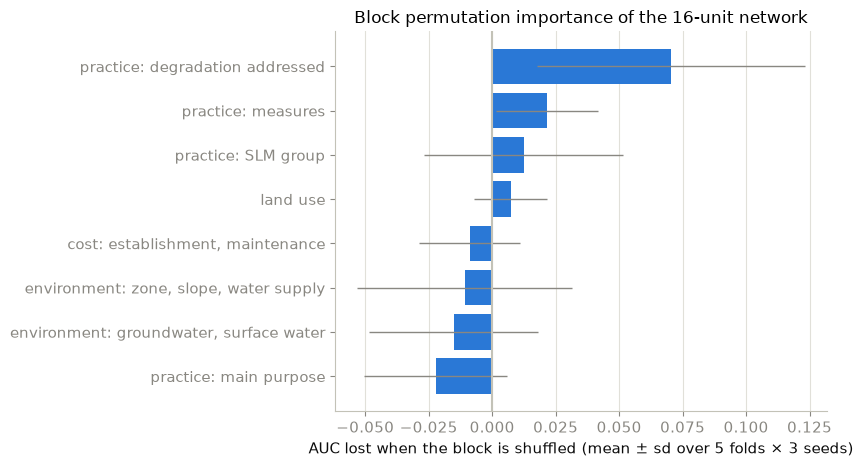

                                          mean    std
practice: main purpose                  -0.022  0.028
environment: groundwater, surface water -0.015  0.033
environment: zone, slope, water supply  -0.011  0.042
cost: establishment, maintenance        -0.009  0.020
land use                                 0.007  0.014
practice: SLM group                      0.012  0.039
practice: measures                       0.021  0.020
practice: degradation addressed          0.070  0.053


In [15]:
BLOCKS = {"environment: zone, slope, water supply": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] in ("agroclimatic_zone", "slope", "watersupply")],
          "environment: groundwater, surface water": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] in ("groundwater", "surfacewater")],
          "cost: establishment, maintenance": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] in COST],
          "land use": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] in LAND_USE],
          "practice: SLM group": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "slm_group"],
          "practice: measures": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "measures"],
          "practice: degradation addressed": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "degradation"],
          "practice: main purpose": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "main_purpose"]}
rng = np.random.default_rng(SEED); rows = []
for model, (tr, te) in zip(models_small, FOLDS * len(SEEDS)):
    base = roc_auc_score(y[te], model.predict(X[te], verbose=0).ravel())
    for name, cols in BLOCKS.items():
        drops = []
        for _ in range(5):
            Xp = X[te].copy(); Xp[:, cols] = Xp[rng.permutation(len(te))][:, cols]
            drops.append(base - roc_auc_score(y[te], model.predict(Xp, verbose=0).ravel()))
        rows.append({"block": name, "AUC drop": np.mean(drops)})
block_imp = pd.DataFrame(rows).groupby("block")["AUC drop"].agg(["mean", "std"]).sort_values("mean")
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.barh(block_imp.index, block_imp["mean"], xerr=block_imp["std"], color=C_BLUE, error_kw=dict(ecolor=INK_MUTED, lw=1))
ax.axvline(0, color=NEUTRAL); ax.set_xlabel("AUC lost when the block is shuffled (mean ± sd over 5 folds × 3 seeds)")
ax.set_title("Block permutation importance of the 16-unit network"); ax.grid(True, axis="x")
plt.tight_layout(); plt.show()
print(block_imp.round(3).rename_axis(None).to_string())

### 6.4 Synthesis: the answer to the research question

* **How much is ticked predicts more than what is ticked.** Two integers, the number of degradation types and the number of measures a technology addresses, reach AUC 0.637 on unseen regions. All 102 questionnaire fields of the research plan reach 0.570. The permutation test agrees from the network's side: shuffling the degradation block costs the network 0.07 (± 0.05) AUC and the measures block 0.02, while every other block, the water and cost fields included, costs nothing measurable (section 6.3). The strongest predictor of a reported top biomass score is how comprehensively a technology is described, which is as much a trace of the compiler as of the land.
* **The plan's water and cost inputs change nothing.** Groundwater table, surface water and the two costs score below chance on their own (AUC 0.45) and cost 0.04 AUC when added to the other fields.
* **No single field is robust.** The full notebook's bootstrap pass under an ordinal target, a thoroughness block and a rater-adjusted target leaves none of the 77 readable coefficients clearly away from zero in every reading, and shows the two strangest signs, wind erosion and a biodiversity purpose, to be artefacts of the +3 cut and of the compiler's thoroughness.
* **Agroforestry, drainage, ground cover, forest, rotational systems and windbreak form the top group** of the what-if, with raw shares of 0.35 to 0.41 and out-of-fold what-if probabilities of 0.33 to 0.36. Drainage rests on 17 records, below the 20 that section 4 asks for before it reads a coefficient, so its place is the least certain of the six. **Water harvesting and crop-livestock integration trail** in every view: raw shares of 0.16, last places in the what-if, and mean ratings of +1.53 and +1.71 against +2.04 for forest and +2.09 for agroforestry.
* **Holding the environment fixed keeps the same groups on top, reshuffled,** and compresses the range, from 0.16 to 0.41 down to 0.23 to 0.36. The network barely uses the SLM group (section 6.3), so switching it cannot move a probability far. The level is right, mean P(high) 0.32 for a class share of 0.30, but it is the order and the gaps that carry the answer, not the height of the blue dots.
* **The environment's signal is the agro-climatic zone.** Arid sites report a +3 in 45 % of records, semi-arid in 34 %, humid and sub-humid in 23 %, and the zone what-if keeps arid on top and sub-humid last (0.37, 0.32, 0.33, 0.30), with semi-arid and humid level. This is Module 1's "environment first" finding seen from the supervised side. The zone shows in the raw shares, the practice hardly shows at all.
* **The individual indicators are not predictable.** The multi-task network of the full notebook, summarised at the end of section 5, predicts none of the eight biodiversity indicators on unseen regions better than that indicator's training mean (skill -0.22 to +0.01), biomass included, while the same trunk's classification head reaches AUC 0.532. The questionnaire separates the top rating from the rest and locates very little else.


## 7. Conclusions and limitations

**What the numbers cannot say:** Every score is one person's opinion of their own project. There are no failures and no control plots, and compilers who documented many technologies rate systematically higher or lower. The what-if is the network's belief about *reported* impact in a counterfactual it never observed. It describes what the WOCAT community reports, not what works. The cost figures carry caveats of their own: they are totals in a unit the compiler chose, not per hectare, converted at the compiler's exchange rate and not adjusted for inflation, which is why they enter as quartiles.

**Module 2 methods used:** A feed-forward network designed, trained, regularised and sized with the D1 toolbox; a wide and deep network is the comparison, and on 479 rows the two are level, the small one slightly ahead. A multi-output network built with the functional API and a custom masked loss (method 2 of the full notebook, an extension of the course's multi-output and custom-loss examples) was tried as well, see the end of section 5. Grouped cross-validation repeated over three seeds, out-of-fold ensembling and permutation importance, for honest evaluation. On 479 rows of one-hot answers the networks find no interactions worth their extra variance, which the yardstick is there to detect. That is a result about the data, not a failure of the methods.

**Next steps:** All seven essential inputs of the research plan are in the model and none of them moves the answer, so the next gains lie with the starting conditions rather than with more practice fields. The same API records hold the site's own biodiversity before the technology (`speciesdiversity`, `habitatdiversity`, questionnaire section 5.5) and the free-text quantities before and after each impact indicator (`quantity_before`, `quantity_after`), which would test directly what section 4 can only infer: that a large reported gain is a small starting point. And compiler-grouped folds, with the whole evaluation repeated over several block seeds, would measure how much of the remaining signal is who filled in the form and give the headline an honest error bar.
